# Sentiment and Future Return Analysis

This notebook evaluates whether the current offline LLM sentiment labels have observable relationships with future returns. It uses already-processed local SQLite tables only; it does not call Groq, FastAPI, or the frontend.

The analysis is descriptive and exploratory. It is not investment advice.


In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "backend" / "data" / "twstock_sentiment.db"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.unicode_minus"] = False

RETURN_COLUMNS = ["future_return_1d", "future_return_3d", "future_return_5d"]
SENTIMENT_ORDER = ["negative", "neutral", "positive"]


## Load Data

Read the local analysis tables from SQLite. The merged `analysis_df` is the main row-level dataset used below.


In [2]:
with sqlite3.connect(DB_PATH) as conn:
    aligned = pd.read_sql_query("SELECT * FROM aligned_news_returns", conn)
    daily = pd.read_sql_query("SELECT * FROM daily_sentiment", conn)
    llm = pd.read_sql_query("SELECT * FROM llm_news_analysis", conn)
    raw = pd.read_sql_query("SELECT id AS news_id, title, published_at, source, url FROM raw_news", conn)

analysis_df = (
    aligned
    .merge(llm[["news_id", "status", "sentiment", "confidence", "target", "reason", "model_name"]], on="news_id", how="left", suffixes=("", "_llm"))
    .merge(raw, on="news_id", how="left")
)
analysis_df["trading_date"] = pd.to_datetime(analysis_df["trading_date"], errors="coerce")
analysis_df["published_at"] = pd.to_datetime(analysis_df["published_at"], errors="coerce")

print(f"DB path: {DB_PATH}")
print(f"aligned rows: {len(aligned):,}")
print(f"daily rows: {len(daily):,}")
print(f"llm rows: {len(llm):,}")
analysis_df.head()


DB path: C:\python_data_analysis_final\backend\data\twstock_sentiment.db
aligned rows: 634
daily rows: 137
llm rows: 1,315


,news_id,trading_date,target,news_type,sentiment_score,future_return_1d,future_return_3d,future_return_5d,status,sentiment,confidence,target_llm,reason,model_name,title,published_at,source,url
0,240,2026-05-07,0050,etf,0.00,-0.007165,-0.008700,-0.016888,success,neutral,0.50,0050,證交所研議中,llama-3.3-70b-versatile,0050開放加掛不配息級別？證交所：3個月給方向,2026-05-07 04:55:43+00:00,Yahoo Stock News,https://tw.stock.yahoo.com/news/0050%E9%96%8B%...
1,1227,2026-06-08,0050,etf,-0.80,NaN,NaN,NaN,success,negative,0.80,0050,遭外資大提款113億元，賣出正2達9344張,meta-llama/llama-4-scout-17b-16e-instruct,換股8檔納入「載板三雄2檔」！「這ETF」卻遭外資大提款113億元 再脫手正2達9344張給...,NaT,Yahoo Stock News,https://tw.stock.yahoo.com/news/%E6%8F%9B%E8%8...
2,1228,2026-06-08,0050,etf,-0.85,NaN,NaN,NaN,success,negative,0.85,0050,外資賣超,llama-3.3-70b-versatile,外資賣超史上第7大 調節0050、主動式ETF,NaT,Yahoo Stock News,https://tw.stock.yahoo.com/news/%E5%A4%96%E8%B...
3,516,2026-05-07,2382,industry,0.00,-0.010174,-0.011628,-0.027616,success,neutral,0.50,Apple Inc.,,llama-3.3-70b-versatile,MacBook Neo大缺貨 傳蘋果要求供應商產能翻倍,NaT,Yahoo Finance Search API:2330,https://tw.stock.yahoo.com/news/macbook-neo%E5...
4,516,2026-05-07,2317,industry,0.00,-0.013807,-0.013807,-0.035503,success,neutral,0.50,Apple Inc.,,llama-3.3-70b-versatile,MacBook Neo大缺貨 傳蘋果要求供應商產能翻倍,NaT,Yahoo Finance Search API:2330,https://tw.stock.yahoo.com/news/macbook-neo%E5...


## Data Overview


In [3]:
def non_null_ratio(series: pd.Series) -> float:
    return float(series.notna().mean()) if len(series) else 0.0

overview = pd.DataFrame({
    "metric": [
        "aligned_news_returns rows",
        "future_return_1d non-null ratio",
        "future_return_3d non-null ratio",
        "future_return_5d non-null ratio",
    ],
    "value": [
        len(aligned),
        non_null_ratio(aligned["future_return_1d"]),
        non_null_ratio(aligned["future_return_3d"]),
        non_null_ratio(aligned["future_return_5d"]),
    ],
})
overview


,metric,value
0,aligned_news_returns rows,634.000000
1,future_return_1d non-null ratio,0.944795
2,future_return_3d non-null ratio,0.826498
3,future_return_5d non-null ratio,0.698738


In [4]:
news_type_distribution = analysis_df["news_type"].value_counts(dropna=False).rename_axis("news_type").reset_index(name="count")
sentiment_distribution = analysis_df["sentiment"].value_counts(dropna=False).rename_axis("sentiment").reset_index(name="count")
target_distribution = analysis_df["target"].value_counts(dropna=False).rename_axis("target").reset_index(name="count")

display(Markdown("### News Type Distribution"))
display(news_type_distribution)
display(Markdown("### Sentiment Distribution"))
display(sentiment_distribution)
display(Markdown("### Target Distribution"))
display(target_distribution)


### News Type Distribution

,news_type,count
0,market,311
1,stock,252
2,industry,68
3,etf,3


### Sentiment Distribution

,sentiment,count
0,positive,341
1,neutral,181
2,negative,112


### Target Distribution

,target,count
0,2330,237
1,0050,216
2,2454,49
3,2317,24
4,2308,18
5,2408,10
6,2303,10
7,3711,8
8,2382,8
9,3231,6


## Sentiment Distribution


In [5]:
sentiment_counts = (
    analysis_df["sentiment"]
    .value_counts()
    .reindex(SENTIMENT_ORDER, fill_value=0)
    .rename_axis("sentiment")
    .reset_index(name="count")
)
sentiment_counts["ratio"] = sentiment_counts["count"] / sentiment_counts["count"].sum()
sentiment_counts


,sentiment,count,ratio
0,negative,112,0.176656
1,neutral,181,0.285489
2,positive,341,0.537855


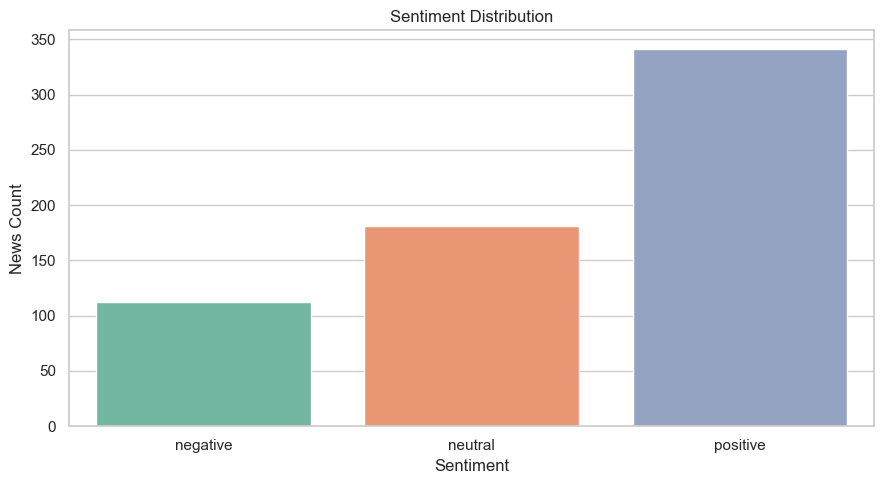

In [6]:
fig, ax = plt.subplots()
sns.barplot(data=sentiment_counts, x="sentiment", y="count", order=SENTIMENT_ORDER, ax=ax, palette="Set2", hue="sentiment", legend=False)
ax.set_title("Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("News Count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sentiment_distribution.png", dpi=160)
plt.show()


In [7]:
sentiment_by_news_type = (
    analysis_df.groupby(["news_type", "sentiment"], dropna=False)
    .size()
    .reset_index(name="count")
)
sentiment_by_news_type["ratio_within_news_type"] = sentiment_by_news_type["count"] / sentiment_by_news_type.groupby("news_type")["count"].transform("sum")
sentiment_by_news_type


,news_type,sentiment,count,ratio_within_news_type
0,etf,negative,2,0.666667
1,etf,neutral,1,0.333333
2,industry,negative,10,0.147059
3,industry,neutral,22,0.323529
4,industry,positive,36,0.529412
5,market,negative,68,0.218650
6,market,neutral,83,0.266881
7,market,positive,160,0.514469
8,stock,negative,32,0.126984
9,stock,neutral,75,0.297619


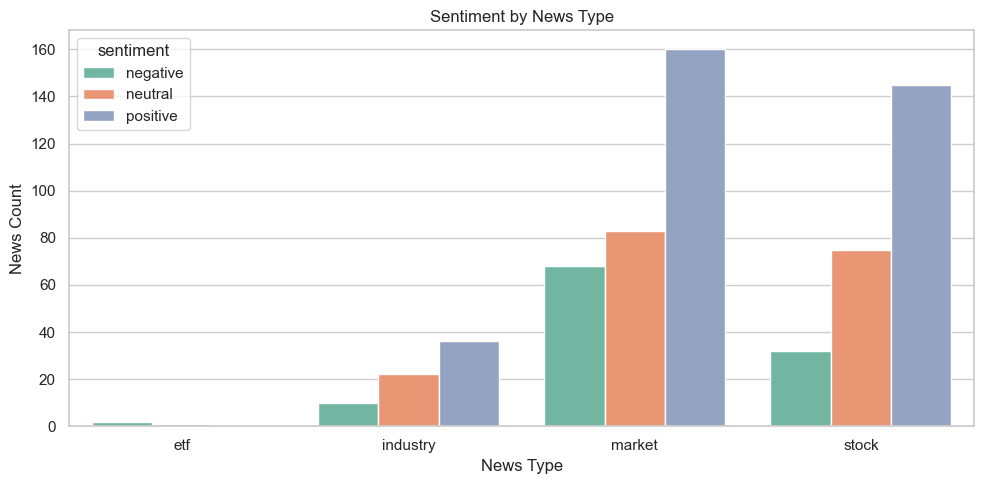

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=sentiment_by_news_type,
    x="news_type",
    y="count",
    hue="sentiment",
    hue_order=SENTIMENT_ORDER,
    palette="Set2",
    ax=ax,
)
ax.set_title("Sentiment by News Type")
ax.set_xlabel("News Type")
ax.set_ylabel("News Count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sentiment_by_news_type.png", dpi=160)
plt.show()


## Sentiment Score and Future Returns

The correlations below use only rows where the relevant future return is non-null.


In [9]:
correlation_rows = []
for col in RETURN_COLUMNS:
    subset = analysis_df[["sentiment_score", col]].dropna()
    correlation_rows.append({
        "return_horizon": col,
        "sample_size": len(subset),
        "pearson_corr": subset["sentiment_score"].corr(subset[col], method="pearson") if len(subset) >= 2 else pd.NA,
        "spearman_corr": subset["sentiment_score"].corr(subset[col], method="spearman") if len(subset) >= 2 else pd.NA,
    })
correlation_summary = pd.DataFrame(correlation_rows)
correlation_summary.to_csv(TABLE_DIR / "correlation_summary.csv", index=False, encoding="utf-8-sig")
correlation_summary


,return_horizon,sample_size,pearson_corr,spearman_corr
0,future_return_1d,599,-0.045304,-0.008673
1,future_return_3d,524,-0.087826,-0.103574
2,future_return_5d,443,-0.016212,-0.104910


In [10]:
sentiment_return_summary = (
    analysis_df.groupby("sentiment", dropna=False)[RETURN_COLUMNS]
    .agg(["count", "mean", "median"])
)
sentiment_return_summary.columns = [f"{return_col}_{stat}" for return_col, stat in sentiment_return_summary.columns]
sentiment_return_summary = sentiment_return_summary.reset_index()
sentiment_return_summary.to_csv(TABLE_DIR / "sentiment_return_summary.csv", index=False, encoding="utf-8-sig")
sentiment_return_summary


,sentiment,future_return_1d_count,future_return_1d_mean,future_return_1d_median,future_return_3d_count,future_return_3d_mean,future_return_3d_median,future_return_5d_count,future_return_5d_mean,future_return_5d_median
0,negative,94,0.006686,-0.008185,71,0.033088,0.032110,69,0.061281,0.055721
1,neutral,177,0.007451,0.000000,156,0.019253,0.025370,136,0.037314,0.024313
2,positive,328,0.004670,0.000000,297,0.010356,0.012739,238,0.026205,0.015801


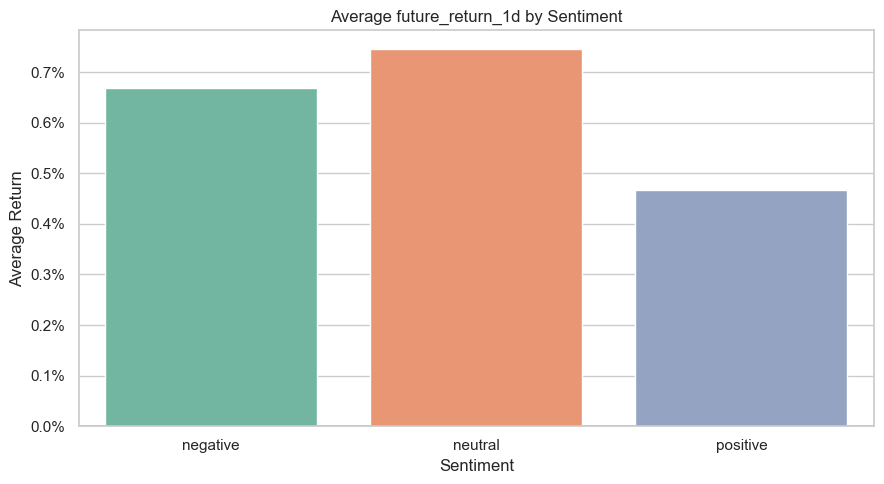

,sentiment,mean,median,count
0,negative,0.006686,-0.008185,94
1,neutral,0.007451,0.000000,177
2,positive,0.004670,0.000000,328


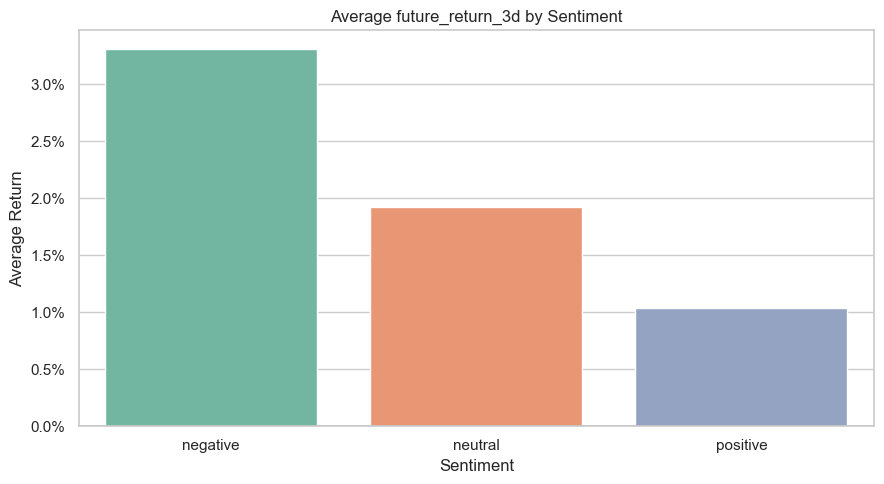

,sentiment,mean,median,count
0,negative,0.033088,0.032110,71
1,neutral,0.019253,0.025370,156
2,positive,0.010356,0.012739,297


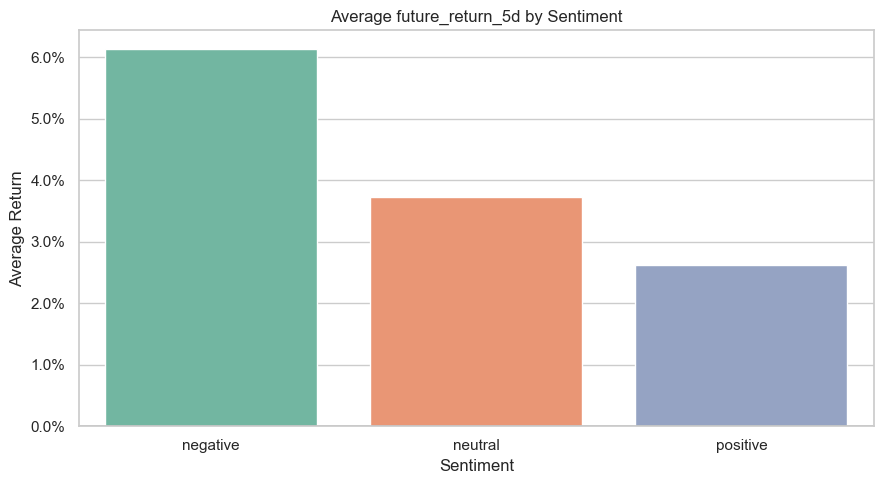

,sentiment,mean,median,count
0,negative,0.061281,0.055721,69
1,neutral,0.037314,0.024313,136
2,positive,0.026205,0.015801,238


In [11]:
def plot_return_by_sentiment(return_col: str, filename: str) -> None:
    summary = (
        analysis_df.groupby("sentiment", dropna=False)[return_col]
        .agg(mean="mean", median="median", count="count")
        .reindex(SENTIMENT_ORDER)
        .reset_index()
    )
    fig, ax = plt.subplots()
    sns.barplot(data=summary, x="sentiment", y="mean", order=SENTIMENT_ORDER, ax=ax, palette="Set2", hue="sentiment", legend=False)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Average {return_col} by Sentiment")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Average Return")
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160)
    plt.show()
    display(summary)

plot_return_by_sentiment("future_return_1d", "return_by_sentiment_1d.png")
plot_return_by_sentiment("future_return_3d", "return_by_sentiment_3d.png")
plot_return_by_sentiment("future_return_5d", "return_by_sentiment_5d.png")


## Return Analysis by News Type

Market and stock rows are the primary analytical groups. Industry rows are listed for visibility, but they should be treated as exploratory unless target normalization and sample construction are reviewed further.


In [12]:
news_type_return_summary = (
    analysis_df.groupby("news_type", dropna=False)[RETURN_COLUMNS]
    .agg(["count", "mean", "median"])
)
news_type_return_summary.columns = [f"{return_col}_{stat}" for return_col, stat in news_type_return_summary.columns]
news_type_return_summary = news_type_return_summary.reset_index()
news_type_return_summary.to_csv(TABLE_DIR / "news_type_return_summary.csv", index=False, encoding="utf-8-sig")
news_type_return_summary


,news_type,future_return_1d_count,future_return_1d_mean,future_return_1d_median,future_return_3d_count,future_return_3d_mean,future_return_3d_median,future_return_5d_count,future_return_5d_mean,future_return_5d_median
0,etf,1,-0.007165,-0.007165,1,-0.008700,-0.008700,1,-0.016888,-0.016888
1,industry,67,0.014802,0.004420,65,0.023784,0.012739,54,0.013971,-0.012616
2,market,297,0.004547,0.000000,280,0.016873,0.025370,238,0.035096,0.024313
3,stock,234,0.004889,-0.008386,178,0.012174,0.012739,150,0.042997,0.015223


In [13]:
for news_type in ["market", "stock", "industry"]:
    subset = analysis_df[analysis_df["news_type"] == news_type]
    display(Markdown(f"### {news_type} news"))
    display(
        subset.groupby("sentiment", dropna=False)[RETURN_COLUMNS]
        .agg(["count", "mean", "median"])
    )


### market news

future_return_1d                     future_return_3d            \
                     count      mean    median            count      mean   
sentiment                                                                   
negative                56  0.003531 -0.008386               40  0.034148   
neutral                 82  0.007556  0.001896               81  0.026291   
positive               159  0.003352  0.000000              159  0.007729   

                    future_return_5d                      
             median            count      mean    median  
sentiment                                                 
negative   0.042424               39  0.065581  0.062171  
neutral    0.028261               74  0.051204  0.040761  
positive   0.015385              125  0.016048  0.017204

### stock news

future_return_1d                     future_return_3d            \
                     count      mean    median            count      mean   
sentiment                                                                   
negative                28  0.005895 -0.008386               22  0.028577   
neutral                 72  0.004795 -0.008386               52  0.003652   
positive               134  0.004729 -0.008386              104  0.012965   

                    future_return_5d                      
             median            count      mean    median  
sentiment                                                 
negative   0.026583               22  0.078566  0.015801  
neutral    0.012739               41  0.020561  0.004246  
positive   0.012739               87  0.044576  0.004246

### industry news

future_return_1d                     future_return_3d            \
                     count      mean    median            count      mean   
sentiment                                                                   
negative                10  0.026567  0.010616                9  0.039402   
neutral                 22  0.016413  0.000000               22  0.031489   
positive                35  0.010427  0.004420               34  0.014665   

                    future_return_5d                      
             median            count      mean    median  
sentiment                                                 
negative   0.012739                8 -0.007217 -0.021530  
neutral    0.014062               20  0.022974 -0.002708  
positive   0.012739               26  0.013566 -0.005662

## Saved Outputs


In [14]:
print("Figures:")
for name in [
    "sentiment_distribution.png",
    "sentiment_by_news_type.png",
    "return_by_sentiment_1d.png",
    "return_by_sentiment_3d.png",
    "return_by_sentiment_5d.png",
]:
    path = FIGURE_DIR / name
    print(f"- {path} ({path.exists()})")

print()
print("Tables:")
for name in ["sentiment_return_summary.csv", "news_type_return_summary.csv", "correlation_summary.csv"]:
    path = TABLE_DIR / name
    print(f"- {path} ({path.exists()})")


Figures:
- C:\python_data_analysis_final\outputs\figures\sentiment_distribution.png (True)
- C:\python_data_analysis_final\outputs\figures\sentiment_by_news_type.png (True)
- C:\python_data_analysis_final\outputs\figures\return_by_sentiment_1d.png (True)
- C:\python_data_analysis_final\outputs\figures\return_by_sentiment_3d.png (True)
- C:\python_data_analysis_final\outputs\figures\return_by_sentiment_5d.png (True)

Tables:
- C:\python_data_analysis_final\outputs\tables\sentiment_return_summary.csv (True)
- C:\python_data_analysis_final\outputs\tables\news_type_return_summary.csv (True)
- C:\python_data_analysis_final\outputs\tables\correlation_summary.csv (True)


## Preliminary Observations

The following text is generated from the current dataset. Treat it as a research note, not an investment recommendation.


In [15]:
def fmt_pct(value):
    if pd.isna(value):
        return "n/a"
    return f"{value:.2%}"

observations = []
observations.append(f"The aligned sample contains {len(analysis_df):,} news rows. 1-day and 3-day future returns are fully populated; 5-day returns are available for {analysis_df['future_return_5d'].notna().sum():,} rows.")

if not correlation_summary.empty:
    strongest = correlation_summary.dropna(subset=["pearson_corr"]).copy()
    if not strongest.empty:
        strongest["abs_corr"] = strongest["pearson_corr"].abs()
        row = strongest.sort_values("abs_corr", ascending=False).iloc[0]
        observations.append(f"The largest absolute Pearson correlation between sentiment_score and future returns is {row['pearson_corr']:.4f} for {row['return_horizon']} with n={int(row['sample_size'])}.")

summary_lookup = sentiment_return_summary.set_index("sentiment")
for col in RETURN_COLUMNS:
    mean_col = f"{col}_mean"
    if mean_col in summary_lookup.columns and {"positive", "negative"}.issubset(summary_lookup.index):
        pos = summary_lookup.loc["positive", mean_col]
        neg = summary_lookup.loc["negative", mean_col]
        observations.append(f"For {col}, positive-sentiment rows average {fmt_pct(pos)} while negative-sentiment rows average {fmt_pct(neg)}.")

if "news_type" in news_type_return_summary.columns:
    primary = news_type_return_summary[news_type_return_summary["news_type"].isin(["market", "stock"])]
    if not primary.empty:
        observations.append("Market and stock news now have enough aligned observations for initial notebook analysis; industry rows remain useful for diagnostics but should be interpreted cautiously.")

observations.append("These observations describe this sample only. They do not establish a stable trading signal or investment advice.")

for item in observations:
    display(Markdown(f"- {item}"))


- The aligned sample contains 634 news rows. 1-day and 3-day future returns are fully populated; 5-day returns are available for 443 rows.

- The largest absolute Pearson correlation between sentiment_score and future returns is -0.0878 for future_return_3d with n=524.

- For future_return_1d, positive-sentiment rows average 0.47% while negative-sentiment rows average 0.67%.

- For future_return_3d, positive-sentiment rows average 1.04% while negative-sentiment rows average 3.31%.

- For future_return_5d, positive-sentiment rows average 2.62% while negative-sentiment rows average 6.13%.

- Market and stock news now have enough aligned observations for initial notebook analysis; industry rows remain useful for diagnostics but should be interpreted cautiously.

- These observations describe this sample only. They do not establish a stable trading signal or investment advice.